In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import json
from pylab import mpl
mpl.rcParams['font.sans-serif'] = ['SimHei']
mpl.rcParams['axes.unicode_minus'] = False


## 读取训练数据

In [2]:

all_lines = []
with open("data/dev.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        one_line = json.loads(line)
        all_lines.append([one_line['sentence'], one_line['label_desc'][5:]])


In [3]:
all_lines[0]


['江疏影甜甜圈自拍，迷之角度竟这么好看，美吸引一切事物', 'entertainment']

In [4]:
all_lines[:5]


[['江疏影甜甜圈自拍，迷之角度竟这么好看，美吸引一切事物', 'entertainment'],
 ['以色列大规模空袭开始！伊朗多个军事目标遭遇打击，誓言对等反击', 'military'],
 ['出栏一头猪亏损300元，究竟谁能笑到最后！', 'finance'],
 ['以前很火的巴铁为何现在只字不提？', 'tech'],
 ['作为一名酒店从业人员，你经历过房客哪些特别没有素质的行为？', 'travel']]

## 查看句子长度

In [5]:
all_lengths = []

In [6]:
for sentence, tag in all_lines:
    all_lengths.append(len(sentence))


In [7]:
all_lengths[:10]


[26, 30, 21, 16, 29, 19, 27, 16, 18, 30]

In [8]:
all_lengths_Series = pd.Series(all_lengths)


In [9]:
all_lengths_Series[:30]


0     26
1     30
2     21
3     16
4     29
5     19
6     27
7     16
8     18
9     30
10    15
11    11
12    29
13    26
14    28
15    22
16    21
17    19
18    53
19    18
20    30
21    13
22    37
23    34
24    28
25    15
26    14
27    18
28    13
29    21
dtype: int64

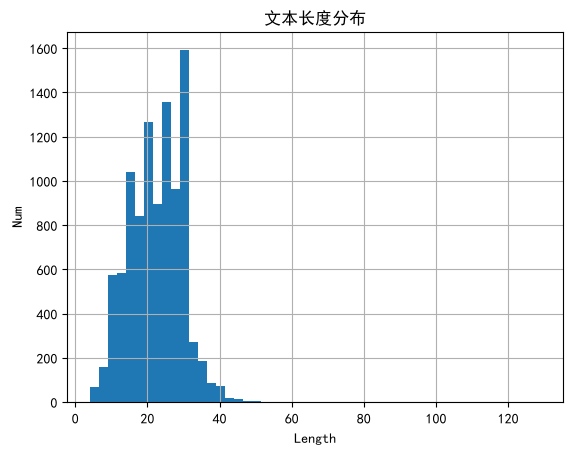

In [10]:
# 查看长度分布的直方图
all_lengths_Series.hist(bins=50)
plt.xlabel('Length')
plt.ylabel('Num')
plt.title('文本长度分布')
plt.show()


In [11]:
# 查看其长度特征
print(all_lengths_Series.describe())


count    10000.000000
mean        22.208900
std          7.355656
min          4.000000
25%         17.000000
50%         23.000000
75%         28.000000
max        129.000000
dtype: float64


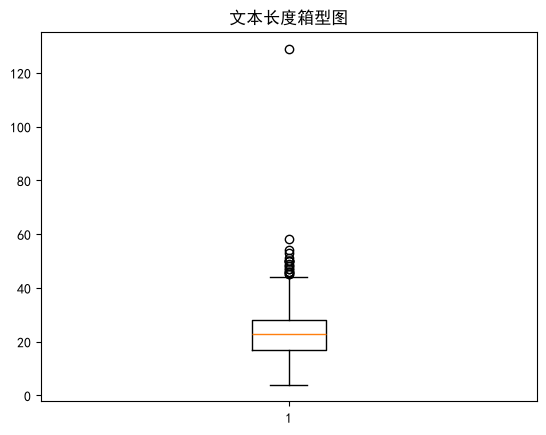

In [12]:
plt.boxplot(all_lengths_Series.tolist(),)
plt.title("文本长度箱型图")
plt.show()


## 查看标签分布

In [13]:
tag_counts_dict = {}

In [14]:
for sentence, tag in all_lines:
    if tag not in tag_counts_dict:
        tag_counts_dict[tag] = 1
    else:
        tag_counts_dict[tag] += 1


In [15]:
tag_counts_dict


{'entertainment': 910,
 'military': 716,
 'finance': 956,
 'tech': 1089,
 'travel': 693,
 'culture': 736,
 'house': 378,
 'edu': 646,
 'agriculture': 494,
 'car': 791,
 'sports': 767,
 'world': 905,
 'game': 659,
 'story': 215,
 'stock': 45}

In [16]:
tag_counts_Series = pd.Series(tag_counts_dict)


In [17]:
tag_counts_Series


entertainment     910
military          716
finance           956
tech             1089
travel            693
culture           736
house             378
edu               646
agriculture       494
car               791
sports            767
world             905
game              659
story             215
stock              45
dtype: int64

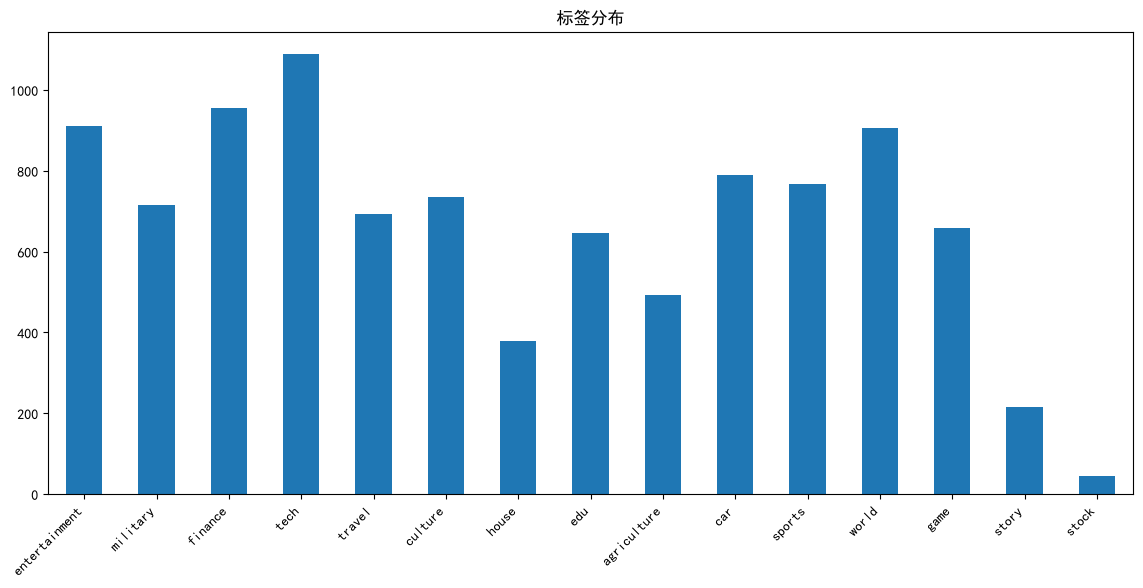

In [23]:
# 标签分布柱形图
plt.figure(figsize=(14, 6)) 
tag_counts_Series.plot.bar()
plt.xticks(rotation=45, ha='right')
plt.title("标签分布")
plt.show()


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


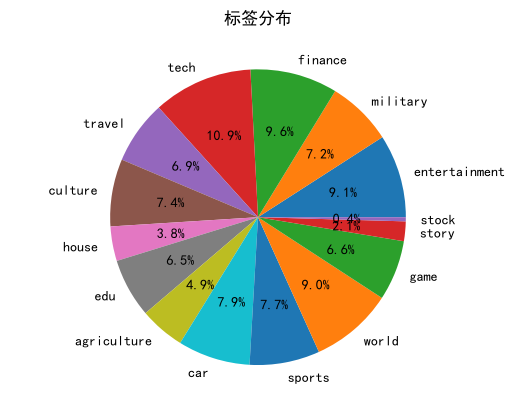

In [19]:
# 标签分布饼图
plt.axis('equal')
values = tag_counts_Series.tolist()
tags = tag_counts_Series.keys().tolist()
plt.pie(values, labels=tags, autopct='%1.1f%%')
plt.title("标签分布")
plt.show()
